In [1]:
import warnings
warnings.simplefilter(action='ignore')

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import torch
import scarches as sca
import sys

 captum (see https://github.com/pytorch/captum).


In [3]:
sc.set_figure_params(frameon=False)
sc.set_figure_params(dpi=200)
sc.set_figure_params(figsize=(4, 4))
torch.set_printoptions(precision=3, sci_mode=False, edgeitems=7)

In [4]:
perc = 1
top_genes = 2000
condition = 'cancer_subtype'

adata_path = f'/home/lgolinelli/git/scarches-1/notebooks/GRN-VAE/anndata_inputs/adata_top_{perc}_top_genes_{top_genes}.h5ad'
model_path = f'/home/lgolinelli/git/scarches-1/notebooks/GRN-VAE/trained_models/model_{perc}_top_genes_{top_genes}_{condition}'

In [5]:
adata = sc.read_h5ad(adata_path)

In [6]:
adata.obs["placeholder_condition"] = "placeholder"

In [7]:
vae = sca.models.EXPIMAP.load(model_path, adata, map_location='cpu')

AnnData object with n_obs × n_vars = 4544 × 1994
    obs: 'cancer_subtype', 'placeholder_condition'
    var: 'gene_ids', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_idx', 'counts_in_terms', 'gene_as_regulator'
    uns: 'cancer_subtype_colors', 'hvg', 'log1p', 'neighbors', 'nsd2_as_regulator', 'nsd2_as_target', 'pca', 'terms', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'I', 'PCs'
    layers: 'X_normalized', 'counts'
    obsp: 'connectivities', 'distances'

INITIALIZING NEW NETWORK..............
Encoder Architecture:
	Input Layer in, out and cond: 1994 300 3
	Hidden Layer 1 in/out: 300 300
	Hidden Layer 2 in/out: 300 300
	Mean/Var Layer in/out: 300 2212
Decoder Architecture:
	Masked linear layer in, ext_m, ext, cond, out:  2212 0 0 3 1994
	with hard mask.
Last Decoder layer: softmax


In [8]:
full_model = vae.model
encoder = full_model.encoder
decoder = full_model.decoder

In [9]:
conditions = adata.obs["placeholder_condition"].values
conditions

array(['placeholder', 'placeholder', 'placeholder', 'placeholder',
       'placeholder', 'placeholder', 'placeholder', ..., 'placeholder',
       'placeholder', 'placeholder', 'placeholder', 'placeholder',
       'placeholder', 'placeholder'], dtype=object)

In [10]:
'''adata.obsm['z1_mean'] = enc_out['z1_mean'].detach().numpy()
sc.pp.neighbors(adata, use_rep='z1_mean')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cancer_subtype'])'''

"adata.obsm['z1_mean'] = enc_out['z1_mean'].detach().numpy()\nsc.pp.neighbors(adata, use_rep='z1_mean')\nsc.tl.umap(adata)\nsc.pl.umap(adata, color=['cancer_subtype'])"

In [11]:
'''sc.pp.neighbors(adata, use_rep='X')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cancer_subtype'])'''

"sc.pp.neighbors(adata, use_rep='X')\nsc.tl.umap(adata)\nsc.pl.umap(adata, color=['cancer_subtype'])"

In [12]:
'''adata.obsm['sample'] = dec_out['sample'].cpu().numpy()
sc.pp.neighbors(adata, use_rep='sample')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cancer_subtype'])'''

"adata.obsm['sample'] = dec_out['sample'].cpu().numpy()\nsc.pp.neighbors(adata, use_rep='sample')\nsc.tl.umap(adata)\nsc.pl.umap(adata, color=['cancer_subtype'])"

In [13]:
'''adata.obsm['dec_mean'] = dec_out['dec_mean'].detach().numpy()
sc.pp.neighbors(adata, use_rep='dec_mean')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cancer_subtype'])'''

"adata.obsm['dec_mean'] = dec_out['dec_mean'].detach().numpy()\nsc.pp.neighbors(adata, use_rep='dec_mean')\nsc.tl.umap(adata)\nsc.pl.umap(adata, color=['cancer_subtype'])"

In [23]:
adata.obs

,cancer_subtype,placeholder_condition,cancer_subtype_perturb,perturbation
AAACCTGAGATGCGAC-1,CRPC-NE,placeholder,CRPC-NE,orig
AAACCTGCACCGGAAA-1,CRPC-NE,placeholder,CRPC-NE,orig
AAACCTGGTAGCCTCG-1,CRPC-adeno,placeholder,CRPC-adeno,orig
AAACCTGGTGTAAGTA-1,DNPC,placeholder,DNPC,orig
AAACCTGGTGTGAATA-1,CRPC-adeno,placeholder,CRPC-adeno,orig
...,...,...,...,...
TTTGTCAGTAAAGGAG-1,CRPC-adeno,placeholder,CRPC-adeno,orig
TTTGTCAGTACTCTCC-1,DNPC,placeholder,DNPC,orig
TTTGTCAGTGTGCCTG-1,CRPC-adeno,placeholder,CRPC-adeno,orig
TTTGTCAGTTGTCTTT-1,DNPC,placeholder,DNPC,orig


In [24]:
pert_gene_adata = vae.perturb_genes(
    adata=adata,
    genes=None,
    perturb_type='Overexpression',
    group_key='cancer_subtype',
    category='CRPC-NE',
    obs_key='perturbation',
    condition_key='cancer_subtype',
    new_condition='CRPC-adeno'
)

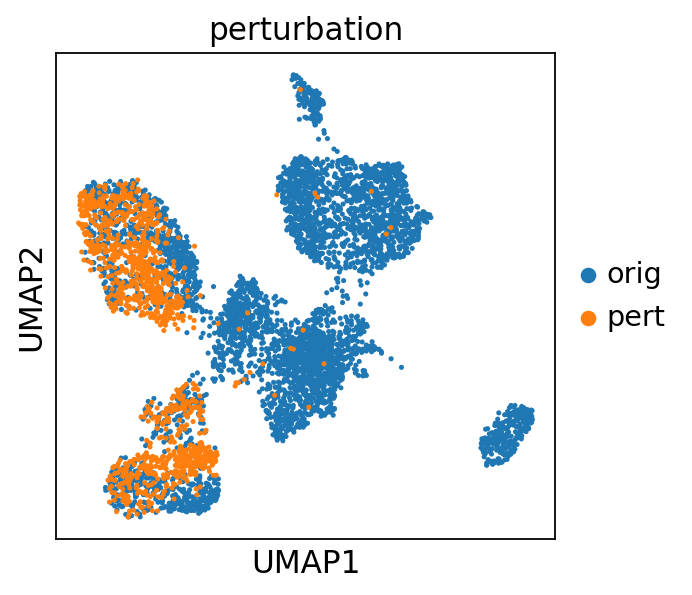

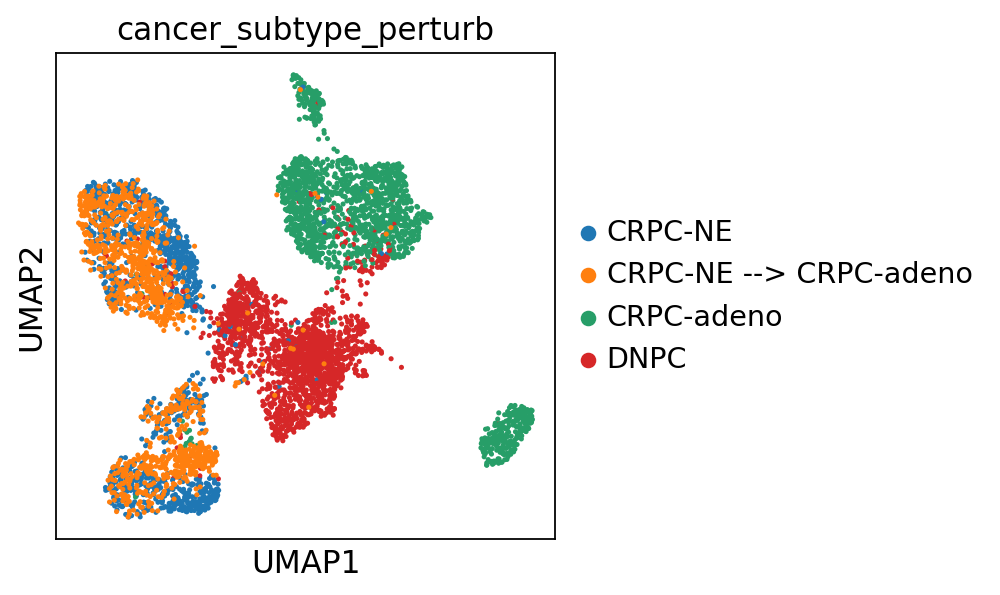

In [25]:
sc.pp.neighbors(pert_gene_adata, use_rep='z1_mean_all')
sc.tl.umap(pert_gene_adata)
sc.pl.umap(pert_gene_adata, color=['perturbation'])
sc.pl.umap(pert_gene_adata, color=['cancer_subtype_perturb'])

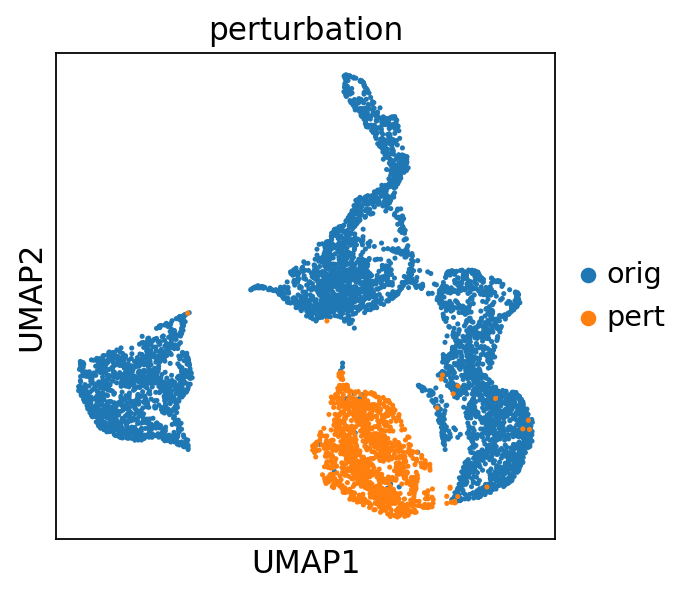

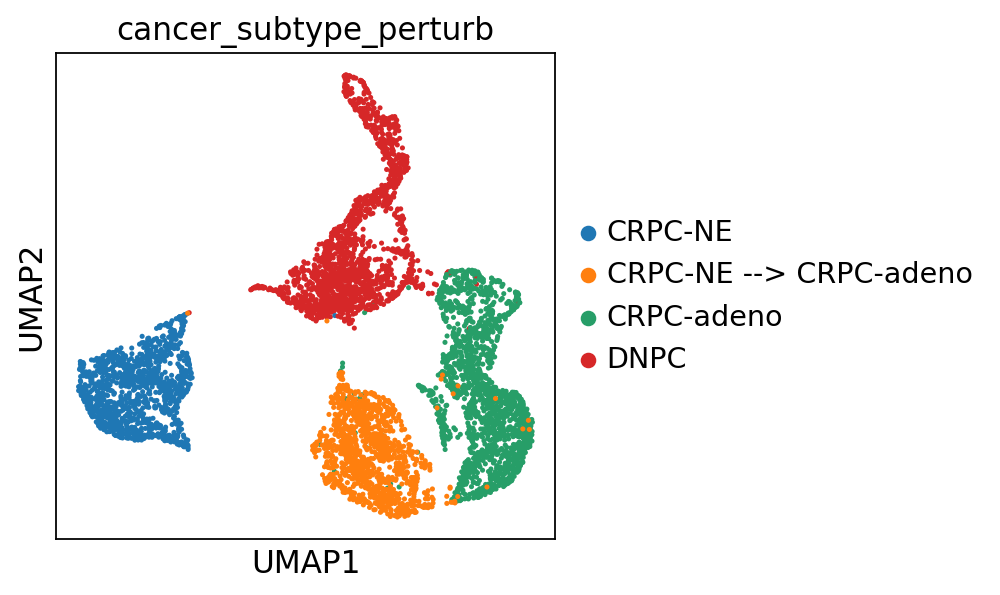

In [26]:
sc.pp.neighbors(pert_gene_adata, use_rep='X')
sc.tl.umap(pert_gene_adata)
sc.pl.umap(pert_gene_adata, color=['perturbation'])
sc.pl.umap(pert_gene_adata, color=['cancer_subtype_perturb'])

In [30]:
pert_gene_adata

AnnData object with n_obs × n_vars = 5709 × 1994
    obs: 'cancer_subtype', 'placeholder_condition', 'cancer_subtype_perturb', 'perturbation'
    uns: 'df_pert_genes_diffs', 'df_pert_programs_diffs', 'neighbors', 'umap', 'perturbation_colors', 'cancer_subtype_perturb_colors'
    obsm: 'X_pca', 'X_umap', 'z1_mean_all'
    layers: 'X_normalized', 'counts', 'perturbed_dec_mean'
    obsp: 'distances', 'connectivities'

In [34]:
pert_gene_adata.obsm['X'] = pert_gene_adata.layers['perturbed_dec_mean']

In [35]:
vae.e_distance(pert_gene_adata, cluster_key='cancer_subtype_perturb', embedding_key='X', n_jobs=-1)

                        CRPC-NE  CRPC-NE --> CRPC-adeno  CRPC-adeno   DNPC
CRPC-NE                  0.0000                  0.1859      0.2014 0.1302
CRPC-NE --> CRPC-adeno                           0.0000      0.0689 0.1409
CRPC-adeno                                                   0.0000 0.1248
DNPC                                                                0.0000


,CRPC-NE,CRPC-NE --> CRPC-adeno,CRPC-adeno,DNPC
CRPC-NE,0.0,0.185929,0.201436,0.130249
CRPC-NE --> CRPC-adeno,NaN,0.000000,0.068852,0.140875
CRPC-adeno,NaN,NaN,0.000000,0.124808
DNPC,NaN,NaN,NaN,0.000000


In [20]:
pert_gene_adata.uns['df_pert_genes_diffs']

,gene_index,gene_name,raw_diff,abs_diff
0,1606,Chga,2.636105e-03,2.636105e-03
1,1980,mt-Nd1,2.057277e-03,2.057277e-03
2,1876,Ttr,1.784842e-03,1.784842e-03
3,1306,Tmem158,1.013525e-03,1.013525e-03
4,1218,Fxyd6,9.121266e-04,9.121266e-04
...,...,...,...,...
1989,198,Thbs1,-5.872425e-08,5.872425e-08
1990,394,Hmgcs2,-5.229322e-08,5.229322e-08
1991,1590,Gm26669,-5.082438e-08,5.082438e-08
1992,681,Gng11,3.450987e-08,3.450987e-08


In [21]:
pert_gene_adata.uns['df_pert_programs_diffs']

,program_index,program_name,raw_diff,abs_diff
0,236,Chga,-7.230953e-01,7.230953e-01
1,405,Eno1,1.097536e-01,1.097536e-01
2,390,Elf3,-1.076014e-01,1.076014e-01
3,789,Irf6,6.769171e-02,6.769171e-02
4,91,Ascl1,-6.476480e-02,6.476480e-02
...,...,...,...,...
2207,27,Actr8,-1.942040e-06,1.942040e-06
2208,1873,Zfp120,-9.683135e-07,9.683135e-07
2209,1064,Nfat5,6.855425e-07,6.855425e-07
2210,1074,Nfic,-4.853937e-07,4.853937e-07


In [27]:
pert_gp_adata = vae.perturb_gps(
    adata=adata,
    programs=None,
    perturb_type='KO',
    group_key='cancer_subtype',
    category='CRPC-NE',
    obs_key='perturbation',
    condition_key='cancer_subtype',
    new_condition='CRPC-adeno'
)

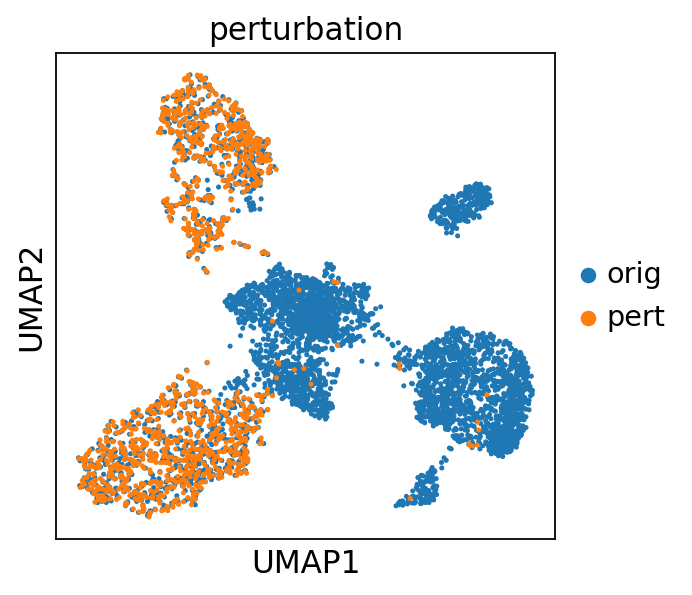

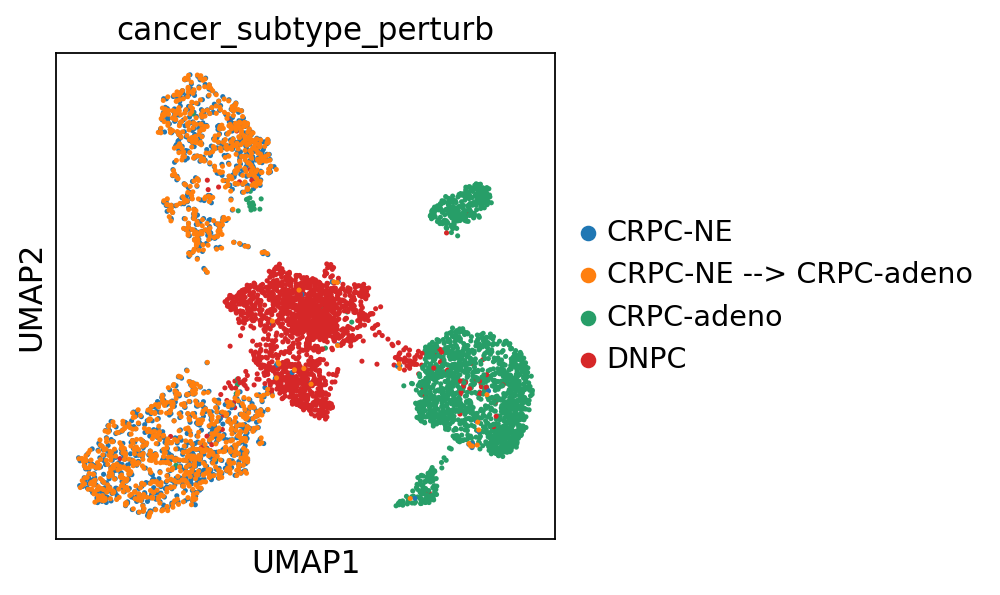

In [28]:
sc.pp.neighbors(pert_gp_adata, use_rep='X_expimap_pert')
sc.tl.umap(pert_gp_adata)
sc.pl.umap(pert_gp_adata, color=['perturbation'])
sc.pl.umap(pert_gp_adata, color=['cancer_subtype_perturb'])

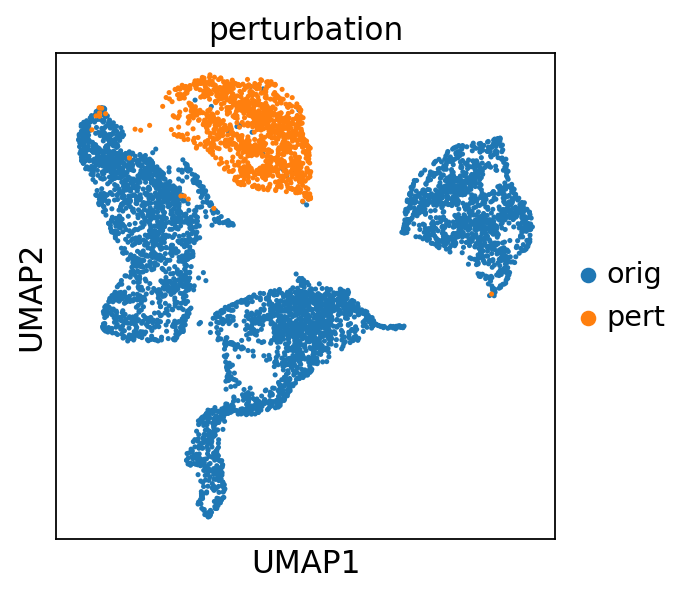

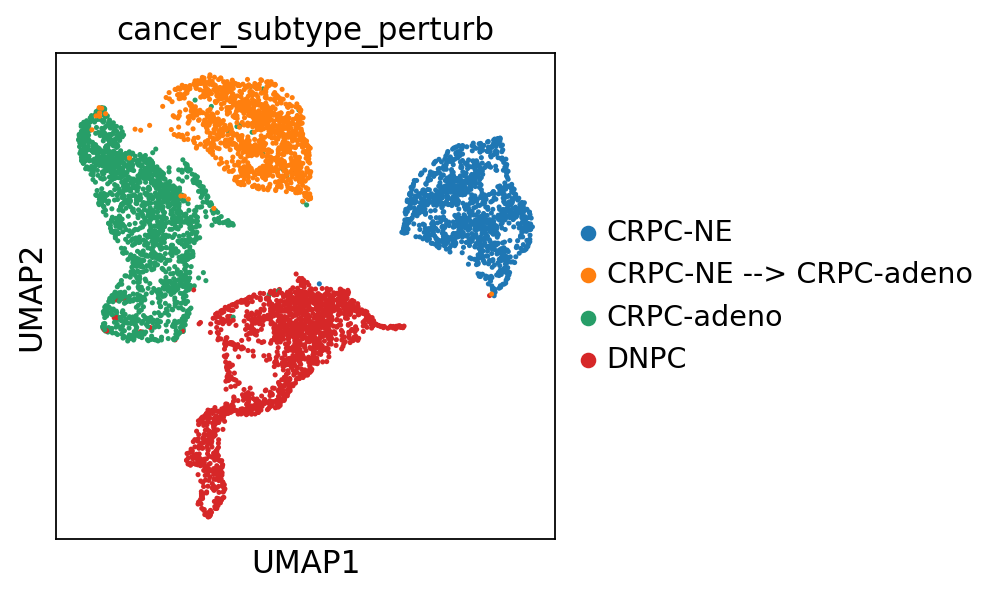

In [29]:
sc.pp.neighbors(pert_gp_adata, use_rep='X')
sc.tl.umap(pert_gp_adata)
sc.pl.umap(pert_gp_adata, color=['perturbation'])
sc.pl.umap(pert_gp_adata, color=['cancer_subtype_perturb'])

In [61]:
pert_gp_adata.uns['df_pert_genes_diffs']

,gene_index,gene_name,raw_diff,abs_diff
0,1980,mt-Nd1,-9.356518e-02,9.356518e-02
1,1937,Malat1,7.846929e-02,7.846929e-02
2,1983,mt-Atp6,2.941072e-02,2.941072e-02
3,1951,Fth1,-1.343526e-02,1.343526e-02
4,669,Actb,1.269110e-02,1.269110e-02
...,...,...,...,...
1989,0,4732440D04Rik,4.207868e-08,4.207868e-08
1990,1270,Gm26882,1.655826e-08,1.655826e-08
1991,833,Klk1b27,1.537592e-08,1.537592e-08
1992,8,Gm38336,-1.098942e-08,1.098942e-08


In [62]:
pert_gp_adata.uns['df_pert_programs_diffs']

,program_index,program_name,raw_diff,abs_diff
0,0,0610010K14Rik,0.0,0.0
1,1477,Skor1,0.0,0.0
2,1471,Six2,0.0,0.0
3,1472,Six3,0.0,0.0
4,1473,Six4,0.0,0.0
...,...,...,...,...
2207,731,Hoxb8,0.0,0.0
2208,730,Hoxb7,0.0,0.0
2209,729,Hoxb6,0.0,0.0
2210,728,Hoxb5,0.0,0.0
